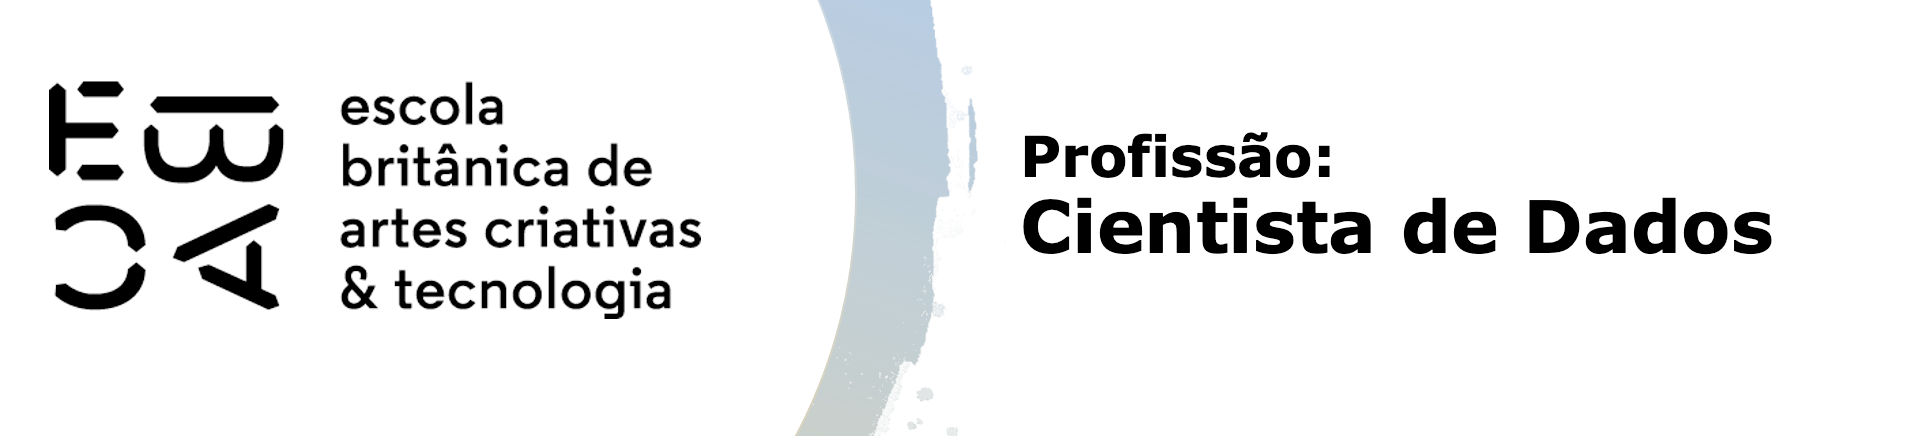

# Tarefa

Com base na tarefa realizada no módulo anterior, vamos fazer um diagnóstico do modelo.

Carregue a base ```previsao_de_renda2.csv```. Separe em uma base de treino e uma base de teste.

Vamos resgatar a melhor versão do modelod e previsão de renda que você fez para esta base. 

- Substitua missings pela média
- Rode novamente o modelo na base de treino (ou desenvolva-o caso não tenha o registro guardado). 

Este modelo deve prever a variável ```renda``` com base nas demais variáveis exceto ```data_ref``` e ```index```. Já vimos que a variável renda é melhor modelada com a transformação ```log()```, não se esqueça disso.

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import patsy
from numpy.ma.core import outer
from statsmodels.stats.outliers_influence import outlier_test


In [57]:
df = pd.read_csv('previsao_de_renda_II.csv', index_col=0)
print(df.head())

            index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
data_ref                                                              
2015-01-01   5762    M                S               N           0   
2015-01-01   1279    M                S               N           0   
2015-01-01  14111    M                S               N           0   
2015-01-01   8189    M                N               S           2   
2015-01-01   1830    F                N               S           2   

             tipo_renda             educacao estado_civil tipo_residencia  \
data_ref                                                                    
2015-01-01   Empresário    Superior completo       Casado            Casa   
2015-01-01  Assalariado  Superior incompleto       Casado            Casa   
2015-01-01  Assalariado    Superior completo       Casado            Casa   
2015-01-01  Assalariado                Médio       Casado            Casa   
2015-01-01  Assalariado    Superior comp

In [58]:
print(df.columns)

Index(['index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel', 'qtd_filhos',
       'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade',
       'tempo_emprego', 'qt_pessoas_residencia', 'renda'],
      dtype='object')


In [59]:
print(df.dropna())

            index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
data_ref                                                              
2015-01-01   5762    M                S               N           0   
2015-01-01   1279    M                S               N           0   
2015-01-01  14111    M                S               N           0   
2015-01-01   8189    M                N               S           2   
2015-01-01   1830    F                N               S           2   
...           ...  ...              ...             ...         ...   
2016-03-01   7163    M                N               S           0   
2016-03-01   1487    M                N               N           0   
2016-03-01  11611    F                N               S           1   
2016-03-01  16583    F                N               S           0   
2016-03-01   3024    F                S               S           1   

                  tipo_renda             educacao estado_civil  \
data_ref  

In [60]:
print(df.index.min())
print(df.index.max())

2015-01-01
2016-03-01


In [61]:
df_train = df[:'2015-12-01']
df_test = df['2016-03-01':]

In [62]:
X1 = patsy.dmatrices('''np.log(renda) ~ C(sexo)
                    + C(posse_de_veiculo)
                    + C(posse_de_imovel)
                    + qtd_filhos
                    + C(tipo_renda)
                    + C(educacao, Treatment(2))
                    + C(estado_civil)
                    + C(tipo_residencia, Treatment(1))
                    + idade
                    + tempo_emprego
                    + qt_pessoas_residencia
                    + 1''', df_train)

## Verifique as suposições do modelo

Faça uma análise para avaliar as suposições básicas:

- Os resíduos desse modelo possuem distribuição Normal (ou algo próximo)?
- Verifique a independência dos resíduos
    - Faça um gráfico dos resíduos versus os valores preditos
    - Avalie se há padrões dos resíduos versus cada uma das variáveis do modelo
    - Avalie se o valor médio dos resíduos aparenta ter relação com o mês de referência
- Avalie se a variância da variável resposta parece ser conforme os valores previstos.

Você considera que as suposições estão atendidas? Há algum impacto em eventuais desvios?

In [63]:
print(df.columns)

Index(['index', 'sexo', 'posse_de_veiculo', 'posse_de_imovel', 'qtd_filhos',
       'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia', 'idade',
       'tempo_emprego', 'qt_pessoas_residencia', 'renda'],
      dtype='object')


/tmp/ipykernel_8738/3134448305.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['renda_pct'] = df_train['renda']/(df_train['tempo_emprego'] - df_train['renda'])
/tmp/ipykernel_8738/3134448305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['log_renda'] = np.log(df_train.renda)
/tmp/ipykernel_8738/3134448305.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the 

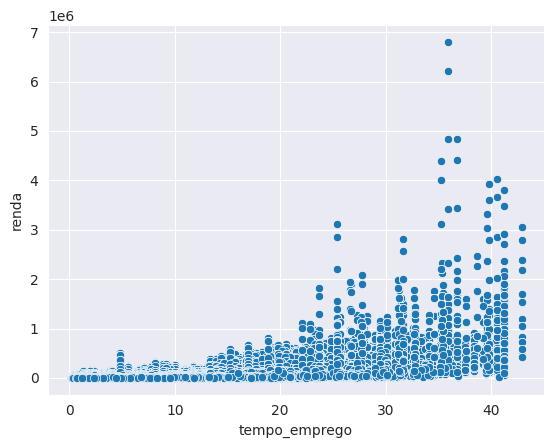

In [64]:
df_train['renda_pct'] = df_train['renda']/(df_train['tempo_emprego'] - df_train['renda'])
df_train['log_renda'] = np.log(df_train.renda)
df_train['log_renda'] = np.log(df_train.qt_pessoas_residencia)
sns.scatterplot(y='renda', x = 'tempo_emprego', data=df_train[df_train['renda_pct']<11.5]);

Esse gráfico acima mostra o tempo de emprego de cada pessoa comparada.
Com sua renda, quanto mais tempo a pessoa tem trabalhado, maior é a sua renda.
Tendem a aumentar, ou pelo fato da pessoa subir de cargo ou seu salário.
Aumenta ao longo do tempo.

In [65]:
reg = smf.ols('renda ~ tempo_emprego', data=df_train).fit()
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  renda   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                 1.556e+05
Date:                Tue, 15 Apr 2025   Prob (F-statistic):               0.00
Time:                        12:43:22   Log-Likelihood:            -6.4324e+06
No. Observations:              499269   AIC:                         1.286e+07
Df Residuals:                  499267   BIC:                         1.286e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -3.041e+04    206.385   -147.352      0.000   -3.08e+04      -3e+04
tempo_emprego  7957.7501     20.172    394.492      0.000    7918.213    7997.287
==============================================================================
Omnibus:                  1146196.008   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      17006864998.035
Skew:                          22.138   Prob(JB):                         0.00
Kurtosis:                     906.086   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

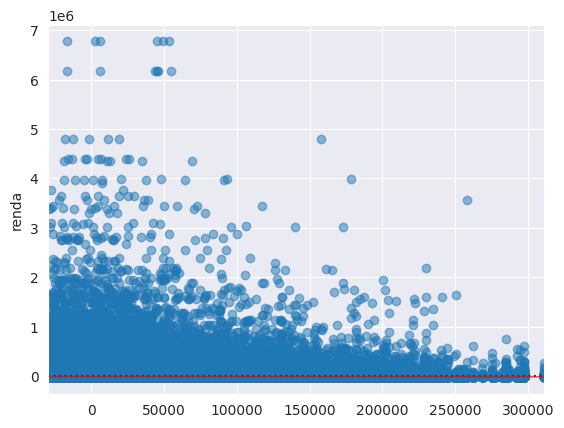

In [66]:
# Generate predictions for the same subset of data used for training
predictions = reg.predict()

# Ensure that the target variable matches the length of predictions
df_train_filtered = df_train.iloc[:len(predictions)]  # Adjust df_train dimensions
actual_renda = df_train_filtered['renda']

# Now plot the residuals
sns.residplot(
    x=predictions,
    y=actual_renda,
    lowess=True,
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8});

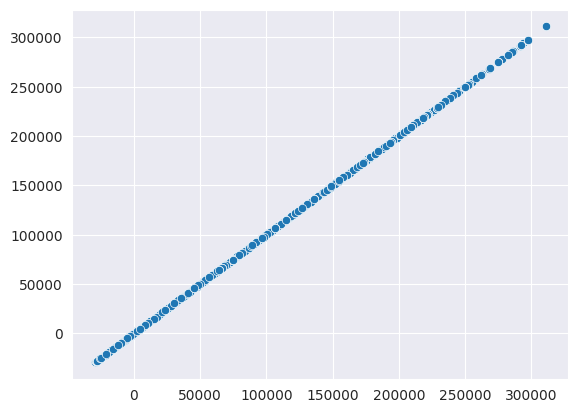

In [67]:
st_res = reg.outlier_test
sns.scatterplot(x = reg.predict(), y = predictions);

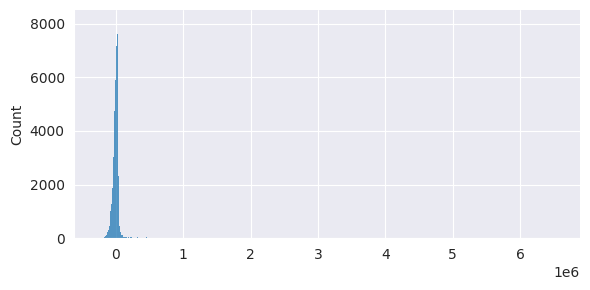

In [68]:
sns.displot(reg.resid, height=3, aspect=2);

<Axes: ylabel='None'>

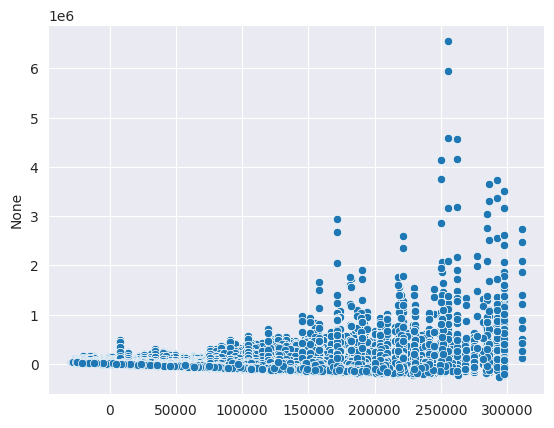

In [69]:
sns.scatterplot(x = reg.predict(), y = reg.resid)

## Outliers

Avalie os *studentized residuals*, verifique se há pontos que parecem ser discrepantes.

Avalie se há pontos influentes.

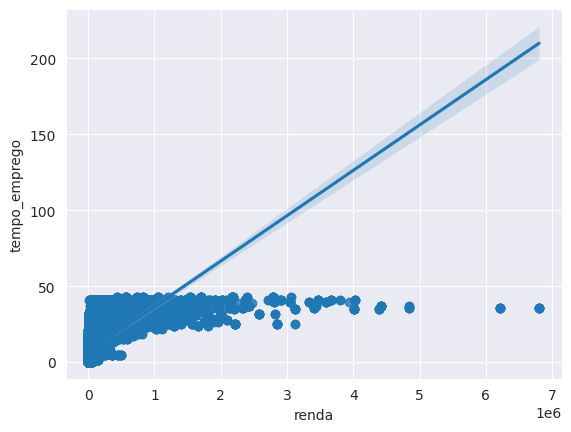

In [81]:
fig, ax = plt.subplots()

sns.regplot(x = 'renda', y = 'tempo_emprego', data=df_train, ax=ax);

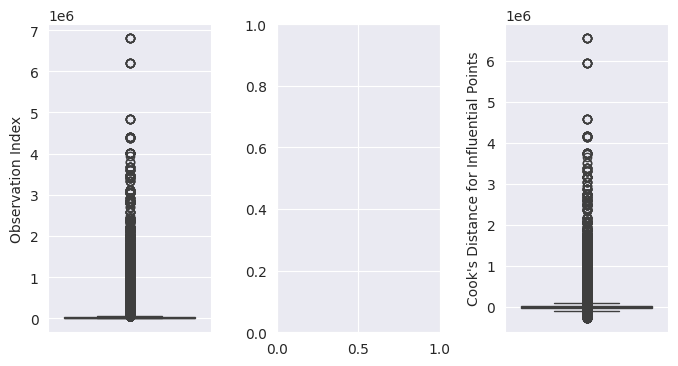

In [91]:
fix, ax = plt.subplots(1, 3, figsize=(8,4))
plt.subplots_adjust(wspace=.4, hspace=0)

sns.boxplot(y = 'renda',data=df_train, ax=ax[0])
#sns.boxplot(y = 'total_bill',data=df, ax=ax[1])
sns.boxplot(y = reg.resid ,data=df_train, ax=ax[2]);

ax[0].set_ylabel("Observation Index")
ax[2].set_ylabel("Cook's Distance")
ax[2].set_ylabel("Cook's Distance for Influential Points");

KeyError: 0

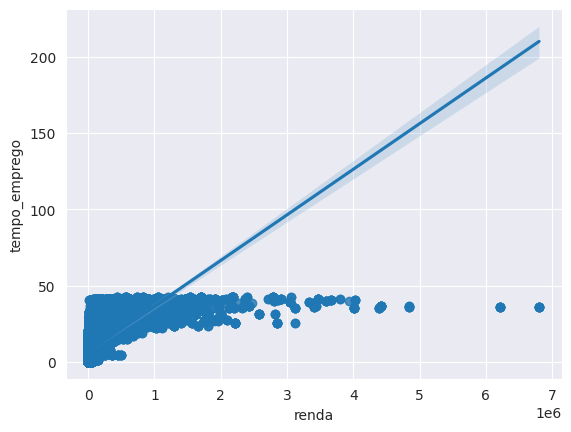

In [95]:
fig, ax = plt.subplots()

sns.regplot(x = 'renda', y = 'tempo_emprego', data=df_train, ax=ax)

for i, txt in enumerate(df_train.index.values):
    ax.annotate(str(txt), (df_train.loc[i,'renda'], df_train.loc[i,'tempo_emprego']))


In [103]:
import statsmodels.api as sm

reg = smf.ols('renda ~ tempo_emprego', data=df_train).fit()

reg.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  renda   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                 1.556e+05
Date:                Tue, 15 Apr 2025   Prob (F-statistic):               0.00
Time:                        15:29:20   Log-Likelihood:            -6.4324e+06
No. Observations:              499269   AIC:                         1.286e+07
Df Residuals:                  499267   BIC:                         1.286e+07
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept     -3.041e+04    206.385   -147.352      0.000   -3.08e+04      -3e+04
tempo_emprego  7957.7501     20.172    394.492      0.000    7918.213    7997.287
==============================================================================
Omnibus:                  1146196.008   Durbin-Watson:                   1.945
Prob(Omnibus):                  0.000   Jarque-Bera (JB):      17006864998.035
Skew:                          22.138   Prob(JB):                         0.00
Kurtosis:                     906.086   Cond. No.                         15.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Multicolinearidade

Avalie se há questões relacionadas a multicolinearidade através de pelo menos:

- Matriz de correlação de Spearman
- VIF

In [ ]:
import scipy.stats as ss
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif

In [105]:
df_train.corr

<bound method DataFrame.corr of             index sexo posse_de_veiculo posse_de_imovel  qtd_filhos  \
data_ref                                                              
2015-01-01   5762    M                S               N           0   
2015-01-01   1279    M                S               N           0   
2015-01-01  14111    M                S               N           0   
2015-01-01   8189    M                N               S           2   
2015-01-01   1830    F                N               S           2   
...           ...  ...              ...             ...         ...   
2015-12-01   4650    F                N               S           1   
2015-12-01   9717    M                S               S           0   
2015-12-01   7485    M                S               S           0   
2015-12-01  15500    F                S               S           1   
2015-12-01   1103    F                S               S           1   

                  tipo_renda             edu

In [112]:
# Converter variáveis categóricas em numéricas (se houver)
df_train_encoded = pd.get_dummies(df_train, drop_first=True)

#selecione apenas colunas numéricas
df_train_numeric = df_train_encoded.select_dtypes(include=['number'])

#calcular a matriz de correlação de Spearman
correlation_matrix = df_train_numeric.corr(method='spearman')

#exibir o resultado
print(correlation_matrix)

                          index  qtd_filhos     idade  tempo_emprego  \
index                  1.000000    0.029364 -0.047196      -0.029787   
qtd_filhos             0.029364    1.000000 -0.415384      -0.053773   
idade                 -0.047196   -0.415384  1.000000       0.265311   
tempo_emprego         -0.029787   -0.053773  0.265311       1.000000   
qt_pessoas_residencia  0.031703    0.828570 -0.350081      -0.027153   
renda                 -0.019073   -0.020244  0.113378       0.596885   
renda_pct              0.000093   -0.018904  0.062690      -0.164814   
log_renda              0.031703    0.828570 -0.350081      -0.027153   

                       qt_pessoas_residencia     renda  renda_pct  log_renda  
index                               0.031703 -0.019073   0.000093   0.031703  
qtd_filhos                          0.828570 -0.020244  -0.018904   0.828570  
idade                              -0.350081  0.113378   0.062690  -0.350081  
tempo_emprego                      

## Ajustes

Faça os ajustes que julgar necessários no modelo e compare as métricas de desempenho do modelo original e ajustado na base de testes.